## DERIVATIVE PRICING
MODULE 5 | LESSON 1


---



# **WORKING WITH STOCK RETURNS**


|  |  |
|:---|:---|
|**Reading Time** |  75 minutes |
|**Prior Knowledge** | Financial time series, Stock returns |
|**Keywords** | API, Yahoo Finance, AlphaVantage, Historical stock returns, Compounding |


---

*In this lesson, we are going to introduce some basic features for downloading, treating, and working with financial data in practice. These are practices we will be using for the remainder of the course (as well as in the Stochastic Modeling course), so make sure you understand the different issues!*

*There are two main topics that we will cover in this notebook:*

- *How to work with APIs in Python to quickly obtain data from different sources.*

- *How to calculate, treat, and work with stock return data in practice.*

*Let's start with the first topic on accessing different APIs to obtain financial data.*<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

## 1. Working with APIs to Obtain Financial Data

An application programming interface (API) is a tool that allows two applications to "talk to each other." In this case, we want our Python script to "talk" to the data repository of some data provider in order to easily extract data in an organized and clean manner. 

Obviously, there are multiple APIs containing financial data: Bloomberg, FactSet, Yahoo! Finance, AlphaVantage, etc. Each API has its own language that allows us to run queries to extract the data. However, the intuition on how these work is virtually the same for every one.

In order to facilitate things, and given the fact that most learners will not have a current subscription to the leading data providers, such as Bloomberg or FactSet (which are indeed very expensive!), we will introduce two APIs that allow us to access the data at no cost.




### 1.1 AlphaVantage API 

This API offers freely available data on stock prices, fundamentals, cryptos, and a wide variety of other data. The only requirement is that you register your email to get a free API key (https://www.alphavantage.co)(Note: You do not have to do this for the course; this is just to illustrate the use of an API*).

All these APIs typically have an associated Python library that allows us to work with them easily. Let's see how AlphaVantage would work:

In [1]:
# import alpha_vantage

Next, let's define our `APIkey`, the ID we can use to access the database. You are free to claim your own API key at the AlphaVantage site if you would like.

In [2]:
APIkey = "PMFNBJ4QM8JEH1KB"

Finally, let's download some data for the historical prices of a particular stock:

In [3]:
from alpha_vantage.timeseries import TimeSeries

ts = TimeSeries(key=APIkey, output_format="pandas")
data, _ = ts.get_daily(symbol="TSLA", outputsize="full")
data = data.loc[
    "2012-01-01":"2021-12-31"
]  # Let's limit our data to the period 2012-2021
data.tail()

/tmp/ipykernel_632/3660899350.py:5: FutureWarning: Value based partial slicing on non-monotonic DatetimeIndexes with non-existing keys is deprecated and will raise a KeyError in a future Version.
  data = data.loc[


,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2012-01-09,27.00,27.49,26.12,27.25,897000.0
2012-01-06,27.20,27.79,26.41,26.91,986300.0
2012-01-05,27.76,27.93,26.85,27.12,1005500.0
2012-01-04,28.21,28.67,27.50,27.71,630100.0
2012-01-03,28.94,29.50,27.65,28.08,928100.0


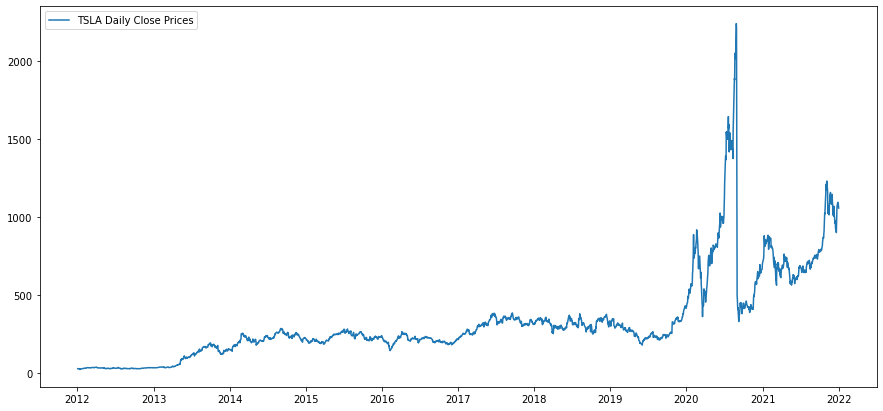

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(data.index, data["4. close"], label="TSLA Daily Close Prices")
plt.legend()
plt.show()

### 1.2 Yahoo! Finance API

Data providers like AlphaVantage (and many others) generally offer a limited amount of data for free, and access to this data sometimes changes with time. There is, however, a somewhat classic API that is well-known for offering freely accessible data: Yahoo! Finance.

We can access the repository of Yahoo! data via the library yfinance. The latest version of yfinance is a complete re-write of the library, offering a reliable method for downloading historical market data from Yahoo! Finance with up to one-minute granularity and a more "Pythonic" way than through the downloading of web data in Excel (like in the old days).

In [5]:
import yfinance as yf

As you will see, the specific grammar may change from API to API, but the intuition is very similar and easy to follow:

In [6]:
# Getting historical market data from Microsoft (MSFT)
msft = yf.Ticker("MSFT")
hist = msft.history(period="5d")
hist

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-09-03 00:00:00-04:00,417.910004,419.880005,407.029999,409.440002,20313600,0.0,0.0
2024-09-04 00:00:00-04:00,405.910004,411.239990,404.369995,408.899994,15135800,0.0,0.0
2024-09-05 00:00:00-04:00,407.619995,413.100006,406.130005,408.390015,14195500,0.0,0.0
2024-09-06 00:00:00-04:00,409.059998,410.649994,400.799988,401.700012,19609500,0.0,0.0
2024-09-09 00:00:00-04:00,407.239990,408.649994,402.149994,405.720001,15275400,0.0,0.0


What is the type of the variable "hist"?

In [7]:
type(hist)

pandas.core.frame.DataFrame

There are some available parameters for the history() method that could come in handy and that we should be aware of:

- **period:** data period to download (either use period parameter or use 'start' and 
'end'). Valid periods are: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max.

- **interval:** data interval (intraday data cannot extend last 60 days) Valid intervals are: 1m, 2m, 5m, 15m, 30m, 60m, 90m, 1h, 1d, 5d, 1wk, 1mo, 3mo

- **start:** If not using period - Download start date string (YYYY-MM-DD) or datetime.

- **end:** If not using period - Download end date string (YYYY-MM-DD) or datetime.

- **prepost:** Include Pre and Post market data in results? (Default is False)

- **auto_adjust:** Adjust all OHLC automatically? (Default is True)

- **actions:** Download stock dividends and stock split events? (Default is True)

Imagine we aim to download the maximum available historical data for MSFT:

In [8]:
msft.history(period="max")

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1986-03-13 00:00:00-05:00,0.054594,0.062623,0.054594,0.059946,1031788800,0.0,0.0
1986-03-14 00:00:00-05:00,0.059947,0.063158,0.059947,0.062087,308160000,0.0,0.0
1986-03-17 00:00:00-05:00,0.062087,0.063694,0.062087,0.063158,133171200,0.0,0.0
1986-03-18 00:00:00-05:00,0.063158,0.063694,0.061017,0.061552,67766400,0.0,0.0
1986-03-19 00:00:00-05:00,0.061552,0.062087,0.059946,0.060482,47894400,0.0,0.0
...,...,...,...,...,...,...,...
2024-09-03 00:00:00-04:00,417.910004,419.880005,407.029999,409.440002,20313600,0.0,0.0
2024-09-04 00:00:00-04:00,405.910004,411.239990,404.369995,408.899994,15135800,0.0,0.0
2024-09-05 00:00:00-04:00,407.619995,413.100006,406.130005,408.390015,14195500,0.0,0.0


Interestingly, you can also download data for multiple tickers at once:

In [9]:
data = yf.download("SPY AAPL MSFT", start="2017-01-01", end="2021-04-30")
data.head()

[*********************100%***********************]  3 of 3 completed


Adj Close                             Close             \
                 AAPL       MSFT         SPY       AAPL       MSFT   
Date                                                                 
2017-01-03  26.921545  56.828140  198.560028  29.037500  62.580002   
2017-01-04  26.891415  56.573883  199.741318  29.004999  62.299999   
2017-01-05  27.028166  56.573883  199.582611  29.152500  62.299999   
2017-01-06  27.329485  57.064255  200.296707  29.477501  62.840000   
2017-01-09  27.579811  56.882629  199.635544  29.747499  62.639999   

                             High                               Low  \
                   SPY       AAPL       MSFT         SPY       AAPL   
Date                                                                  
2017-01-03  225.240005  29.082500  62.840000  225.830002  28.690001   
2017-01-04  226.580002  29.127501  62.750000  226.750000  28.937500   
2017-01-05  226.399994  29.215000  62.660000  226.580002  28.952499   
2017-01-06  227.210007  29.540001  63.150002  227.750000  29.117500   
2017-01-09  226.460007  29.857500  63.080002  227.070007  29.485001   

                                        Open                         \
                 MSFT         SPY       AAPL       MSFT         SPY   
Date                                                                  
2017-01-03  62.130001  223.880005  28.950001  62.790001  225.039993   
2017-01-04  62.119999  225.610001  28.962500  62.480000  225.619995   
2017-01-05  62.029999  225.479996  28.980000  62.189999  226.270004   
2017-01-06  62.040001  225.899994  29.195000  62.299999  226.529999   
2017-01-09  62.540001  226.419998  29.487499  62.759998  226.910004   

               Volume                      
                 AAPL      MSFT       SPY  
Date                                       
2017-01-03  115127600  20694100  91366500  
2017-01-04   84472400  21340000  78744400  
2017-01-05   88774400  24876000  78379000  
2017-01-06  127007600  19922900  71559900  
2017-01-09  134247600  20382700  46939700

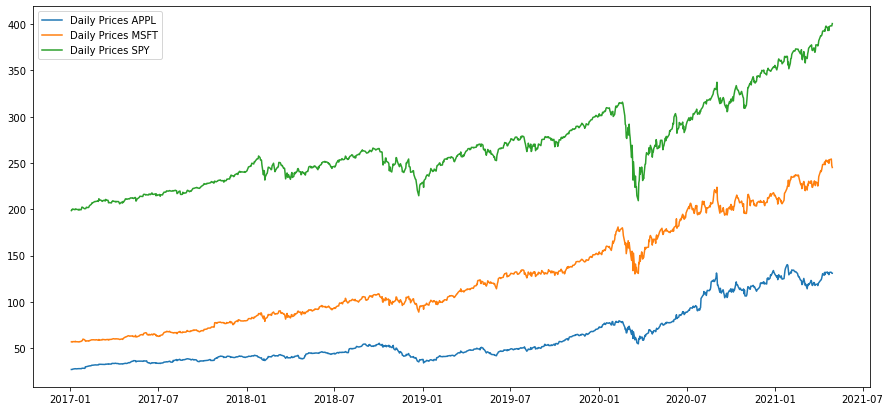

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(data.index, data["Adj Close"]["AAPL"], label="Daily Prices APPL")
plt.plot(data.index, data["Adj Close"]["MSFT"], label="Daily Prices MSFT")
plt.plot(data.index, data["Adj Close"]["SPY"], label="Daily Prices SPY")
plt.legend()
plt.show()

Here the data is by default grouped by "type of price" variable (i.e., Adjusted close, Close, High, etc.). But we can easily change this if we want another type of grouping:

In [11]:
data = yf.download(
    "SPY AAPL MSFT", start="2017-01-01", end="2021-04-30", group_by="ticker"
)
data

[*********************100%***********************]  3 of 3 completed


AAPL                                                  \
                  Open        High         Low       Close   Adj Close   
Date                                                                     
2017-01-03   28.950001   29.082500   28.690001   29.037500   26.921545   
2017-01-04   28.962500   29.127501   28.937500   29.004999   26.891415   
2017-01-05   28.980000   29.215000   28.952499   29.152500   27.028166   
2017-01-06   29.195000   29.540001   29.117500   29.477501   27.329485   
2017-01-09   29.487499   29.857500   29.485001   29.747499   27.579811   
...                ...         ...         ...         ...         ...   
2021-04-23  132.160004  135.119995  132.160004  134.320007  131.686523   
2021-04-26  134.830002  135.059998  133.559998  134.720001  132.078629   
2021-04-27  135.009995  135.410004  134.110001  134.389999  131.755096   
2021-04-28  134.309998  135.020004  133.080002  133.580002  130.961014   
2021-04-29  136.470001  137.070007  132.449997  133.479996  130.862946   

                             MSFT                                      \
               Volume        Open        High         Low       Close   
Date                                                                    
2017-01-03  115127600   62.790001   62.840000   62.130001   62.580002   
2017-01-04   84472400   62.480000   62.750000   62.119999   62.299999   
2017-01-05   88774400   62.189999   62.660000   62.029999   62.299999   
2017-01-06  127007600   62.299999   63.150002   62.040001   62.840000   
2017-01-09  134247600   62.759998   63.080002   62.540001   62.639999   
...               ...         ...         ...         ...         ...   
2021-04-23   78657500  257.880005  261.510010  257.269989  261.149994   
2021-04-26   66905100  261.660004  262.440002  260.170013  261.549988   
2021-04-27   66015800  261.579987  263.190002  260.119995  261.970001   
2021-04-28  107760100  256.079987  256.540009  252.949997  254.559998   
2021-04-29  151101000  255.460007  256.100006  249.000000  252.509995   

                                         SPY                          \
             Adj Close    Volume        Open        High         Low   
Date                                                                   
2017-01-03   56.828148  20694100  225.039993  225.830002  223.880005   
2017-01-04   56.573868  21340000  225.619995  226.750000  225.610001   
2017-01-05   56.573868  24876000  226.270004  226.580002  225.479996   
2017-01-06   57.064251  19922900  226.529999  227.750000  225.899994   
2017-01-09   56.882629  20382700  226.910004  227.070007  226.419998   
...                ...       ...         ...         ...         ...   
2021-04-23  253.520126  21462600  412.869995  418.250000  412.790009   
2021-04-26  253.908463  19763300  417.440002  418.220001  416.809998   
2021-04-27  254.316238  31014200  417.929993  418.140015  416.299988   
2021-04-28  247.122696  46903100  417.809998  419.010010  416.899994   
2021-04-29  245.132553  40589000  420.320007  420.720001  416.440002   

                                              
                 Close   Adj Close    Volume  
Date                                          
2017-01-03  225.240005  198.560059  91366500  
2017-01-04  226.580002  199.741318  78744400  
2017-01-05  226.399994  199.582611  78379000  
2017-01-06  227.210007  200.296677  71559900  
2017-01-09  226.460007  199.635513  46939700  
...                ...         ...       ...  
2021-04-23  416.739990  397.418549  73209200  
2021-04-26  417.609985  398.248260  52182400  
2021-04-27  417.519989  398.162445  51303100  
2021-04-28  417.399994  398.047943  51238900  
2021-04-29  420.059998  400.584625  78544300  

[1088 rows x 18 columns]

Finally, if we are only interested in one of the variables (e.g., adjusted close price) for one of the tickers (e.g., S&P500 index ETF, SPY) we can also store that in a separate variable:

In [12]:
spy_price = data["SPY"]["Adj Close"]
spy_price

Date
2017-01-03    198.560059
2017-01-04    199.741318
2017-01-05    199.582611
2017-01-06    200.296677
2017-01-09    199.635513
                 ...    
2021-04-23    397.418549
2021-04-26    398.248260
2021-04-27    398.162445
2021-04-28    398.047943
2021-04-29    400.584625
Name: Adj Close, Length: 1088, dtype: float64

This is a short and quick introduction to the use of APIs and how to deal with financial data. Now, let's move on to how to work with stock returns, the different ways to calculate them, and the properties associated with each of these ways.



## 2. Working with Stock Returns

First, let's look at the big picture regarding the types of financial data out there:

1.   **Time Series data**: Data collected over a period of time on one or more variables.
2.   **Cross-sectional data**: Cross-sectional data are data on one or more variables collected at a single point in time.
3. **Panel data**: Panel data have the dimensions of both time series and cross-sections, e.g., the daily prices of a number of blue chip stocks over two years.

Now, let's see how to look at stock returns:

### 2.1 Returns in Financial Modeling

There are two methods used to calculate returns from a series of prices, and these involve the calculation of simple returns or continuously compounded returns. 

- Simple returns:


$R_t = \dfrac{p_t - p_{t-1}}{p_{t-1}} \times 100\%$


- Continuously compounded returns:

    
$r_t = ln \left(\dfrac{p_t}{p_{t-1}}\right) \times 100\%$  

\
(Review)  [Continuous and Discrete compounding.](https://financetrain.com/continuous-and-discrete-compounding)

\
Importantly, these two methods yield different outcomes, which we need to be aware of.

In [13]:
import numpy as np

price_0 = 9  # Imagine this is the price at t=0
price_1 = 10  # Imagine this is the price at t=º

# So, returns for the period t=0 to t=1 will be:

Simple_ret = (price_1 - price_0) / price_0 * 100
Cont_ret = np.log(price_1 / price_0) * 100

print("The simple return at t=1 will be ", "{:.4f}".format(Simple_ret), "%")
print(
    "The continuously compounded return at t=1 will be ", "{:.4f}".format(Cont_ret), "%"
)

The simple return at t=1 will be  11.1111 %
The continuously compounded return at t=1 will be  10.5361 %


### **2.2 Returns: Simple Compounding**

We assume that the asset is purchased at time $t-K$ for price $P_{t-K}$
and then sold $K$ periods later at price $P_t$. 

$$
\begin{equation}
\begin{aligned}
    R_{Kt} & = \dfrac{P_t-P_{t-K}}{P_{t-K}} = \dfrac{P_t}{P_{t-K}}-1 \longrightarrow P_{t}=P_{t-K}(1+R_{t}^{K})
\end{aligned}
\end{equation}
$$
In the case of $K=1$:

$$
\begin{equation}
\begin{aligned}
    R_{t} & = \dfrac{P_t-P_{t-1}}{P_{t-1}} = \dfrac{P_t}{P_{t-1}}-1 \longrightarrow P_{t}=P_{t-1}(1+R_{t})
\end{aligned}
\end{equation}
$$

The max and min values would be:
$$
\begin{equation}
\begin{aligned}
    & min (R_t) = -1 = -100\% \\[6pt]
    & max (R_t) = +\infty
\end{aligned}
\end{equation}
$$

### **2.3 Returns: Using Logs (continuously compounded)**

We assume that the asset is purchased at time $t-K$ for price $P_{t-K}$
and then sold $K$ periods later at price $P_t$. 

$$
\begin{equation}
\begin{aligned}
    r_{t}^{K} & = ln\left( \dfrac{P_t}{P_{t-K}} \right) = ln(P_t) - ln(P_{t-K}) \longrightarrow P_{t}=P_{t-K} \exp{r_{t}^{K}}
\end{aligned}
\end{equation}
$$

In the case of $K=1$:

$$
\begin{equation}
\begin{aligned}
    r_{t} & = ln\left( \dfrac{P_t}{P_{t-1}} \right) = ln(P_t) - ln(P_{t-1}) \longrightarrow P_{t}=P_{t-1} \exp{r_{t}}
\end{aligned}
\end{equation}
$$

The max and min values would be:

$$
\begin{equation}
\begin{aligned}
    & min (R_t) = -\infty\\[6pt]
    & max (R_t) = +\infty
\end{aligned}
\end{equation}
$$


### **2.4 Returns: Properties**

Let's assume that the asset is purchased at time $t-K$ for price $P_{t-K}$
and then sold $K$ periods later at price $P_t$. Then, if we calculate simple
returns for each period, $R_{t} , R_{t+1},\ldots, R_{K}$, the aggregate return over all $K$ periods is:

$$
\begin{equation}
\begin{aligned}
    R_{Kt} & = \dfrac{P_t-P_{t-K}}{P_{t-K}} = \dfrac{P_{t}}{P_{t-K}}-1 = 
    \left[\dfrac{P_t}{P_{t-1}} \times \dfrac{P_{t-1}}{P_{t-2}} \ldots \dfrac{P_{t-K-1}}{P_{t-K}}\right] - 1=\\[6pt]
    & = \left[(1+R_t)(1+R_{t-1})\ldots(1+R_{t-K+1})\right] = \prod_{j=0}^{k-1}(1+R_{t-j})
\end{aligned}
\end{equation}
$$

For Log-returns:

$$
\begin{equation}
\begin{aligned}
    r_{t}^{K} & = ln\left( \dfrac{P_t}{P_{t-K}} \right) = ln(P_t) - ln(P_{t-K})=\\[6pt]
    & = [ln(P_t)-ln(P_{t-1})]+\ldots+[ln(P_{t-(K-1)})-ln(P_{t-K})]
\end{aligned}
\end{equation}
$$


### **2.5 Annualized Returns**

If the asset was held for $k$ years, then the annualized (average) return is defined as:

$$
\begin{equation}
    Annualized \mbox{   } {R_t[k]} = \left[\prod_{j=0}^{k-1}(1+R_{t-j}) \right]^{1/k}-1
\end{equation}
$$

This is a geometric mean of the k one-period simple gross returns involved and can be computed by:

$$
\begin{equation}
    Annualized \mbox{   } {R_t[k]} = \exp{\left[\dfrac{1}{k}\sum_{j=0}^{k-1}ln(1+R_{t-j}) \right]}-1
\end{equation}
$$


**Example: Buffet's Returns - How to use the annualized return**

|  |  |  |  |
|----|----|----|----|
|**Period** |  **Berkshire Hathaway** | **S&P500** | **Annual Outperf.**|
|1960s |  28.3% | 5.0% | 23.3%|
|1970s |  22.2% | 5.9% | 16.3%|
|1980s |  39.1% | 17.3% | 21.7%|
|1990s |  20.5% | 18.0% | 2.5%|
|2000s |  5.9% | -1.0% | 6.8%|
|2010s |  17.9% | 15.3% | 2.6%|
|**1965 - 2014** |  **21.7%** | **9.8%** | **11.8%**|

If you invested 100.000 euros in 1965, what is the amount of money in 2014? (Using the average annual return)


In [14]:
A_ret = 0.217
n_year = 2014 - 1965
Initial_invest = 100000

Total_ret = (1 + A_ret) ** n_year
Final_invest = Initial_invest * Total_ret
print("Your investment will be worth " + str(Final_invest / 10**6) + " millions!")

Your investment will be worth 1510.90908737206 millions!


## 3. Conclusion 

Well done! This has been a quick review of concepts that, hopefully, you were already familiar with.

Now, jump to the next lesson to see a practical investigation of the different properties and stylized facts associated with stock returns.

---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
